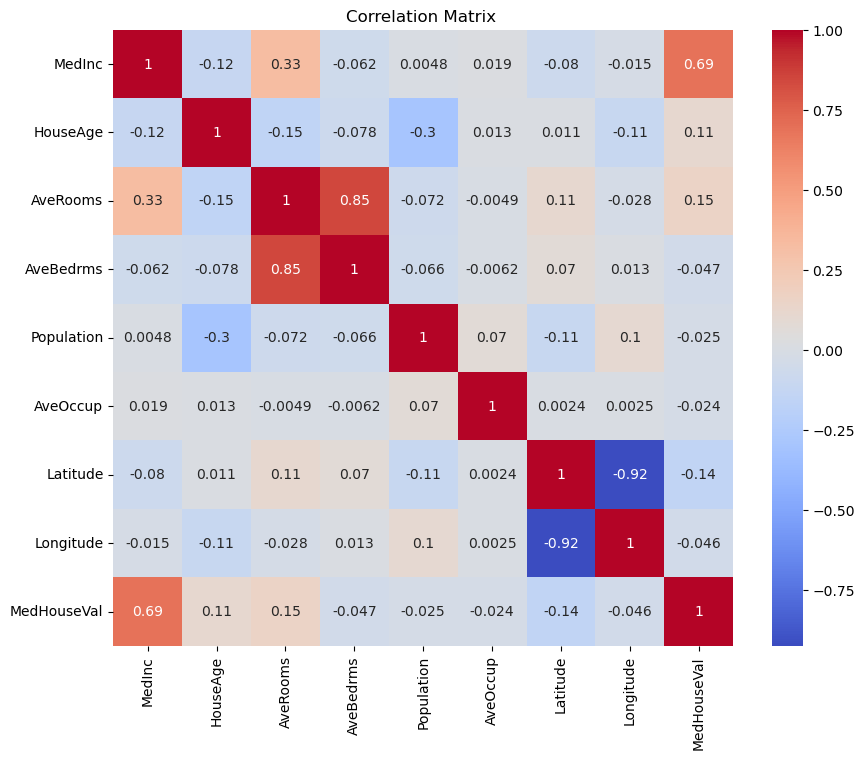

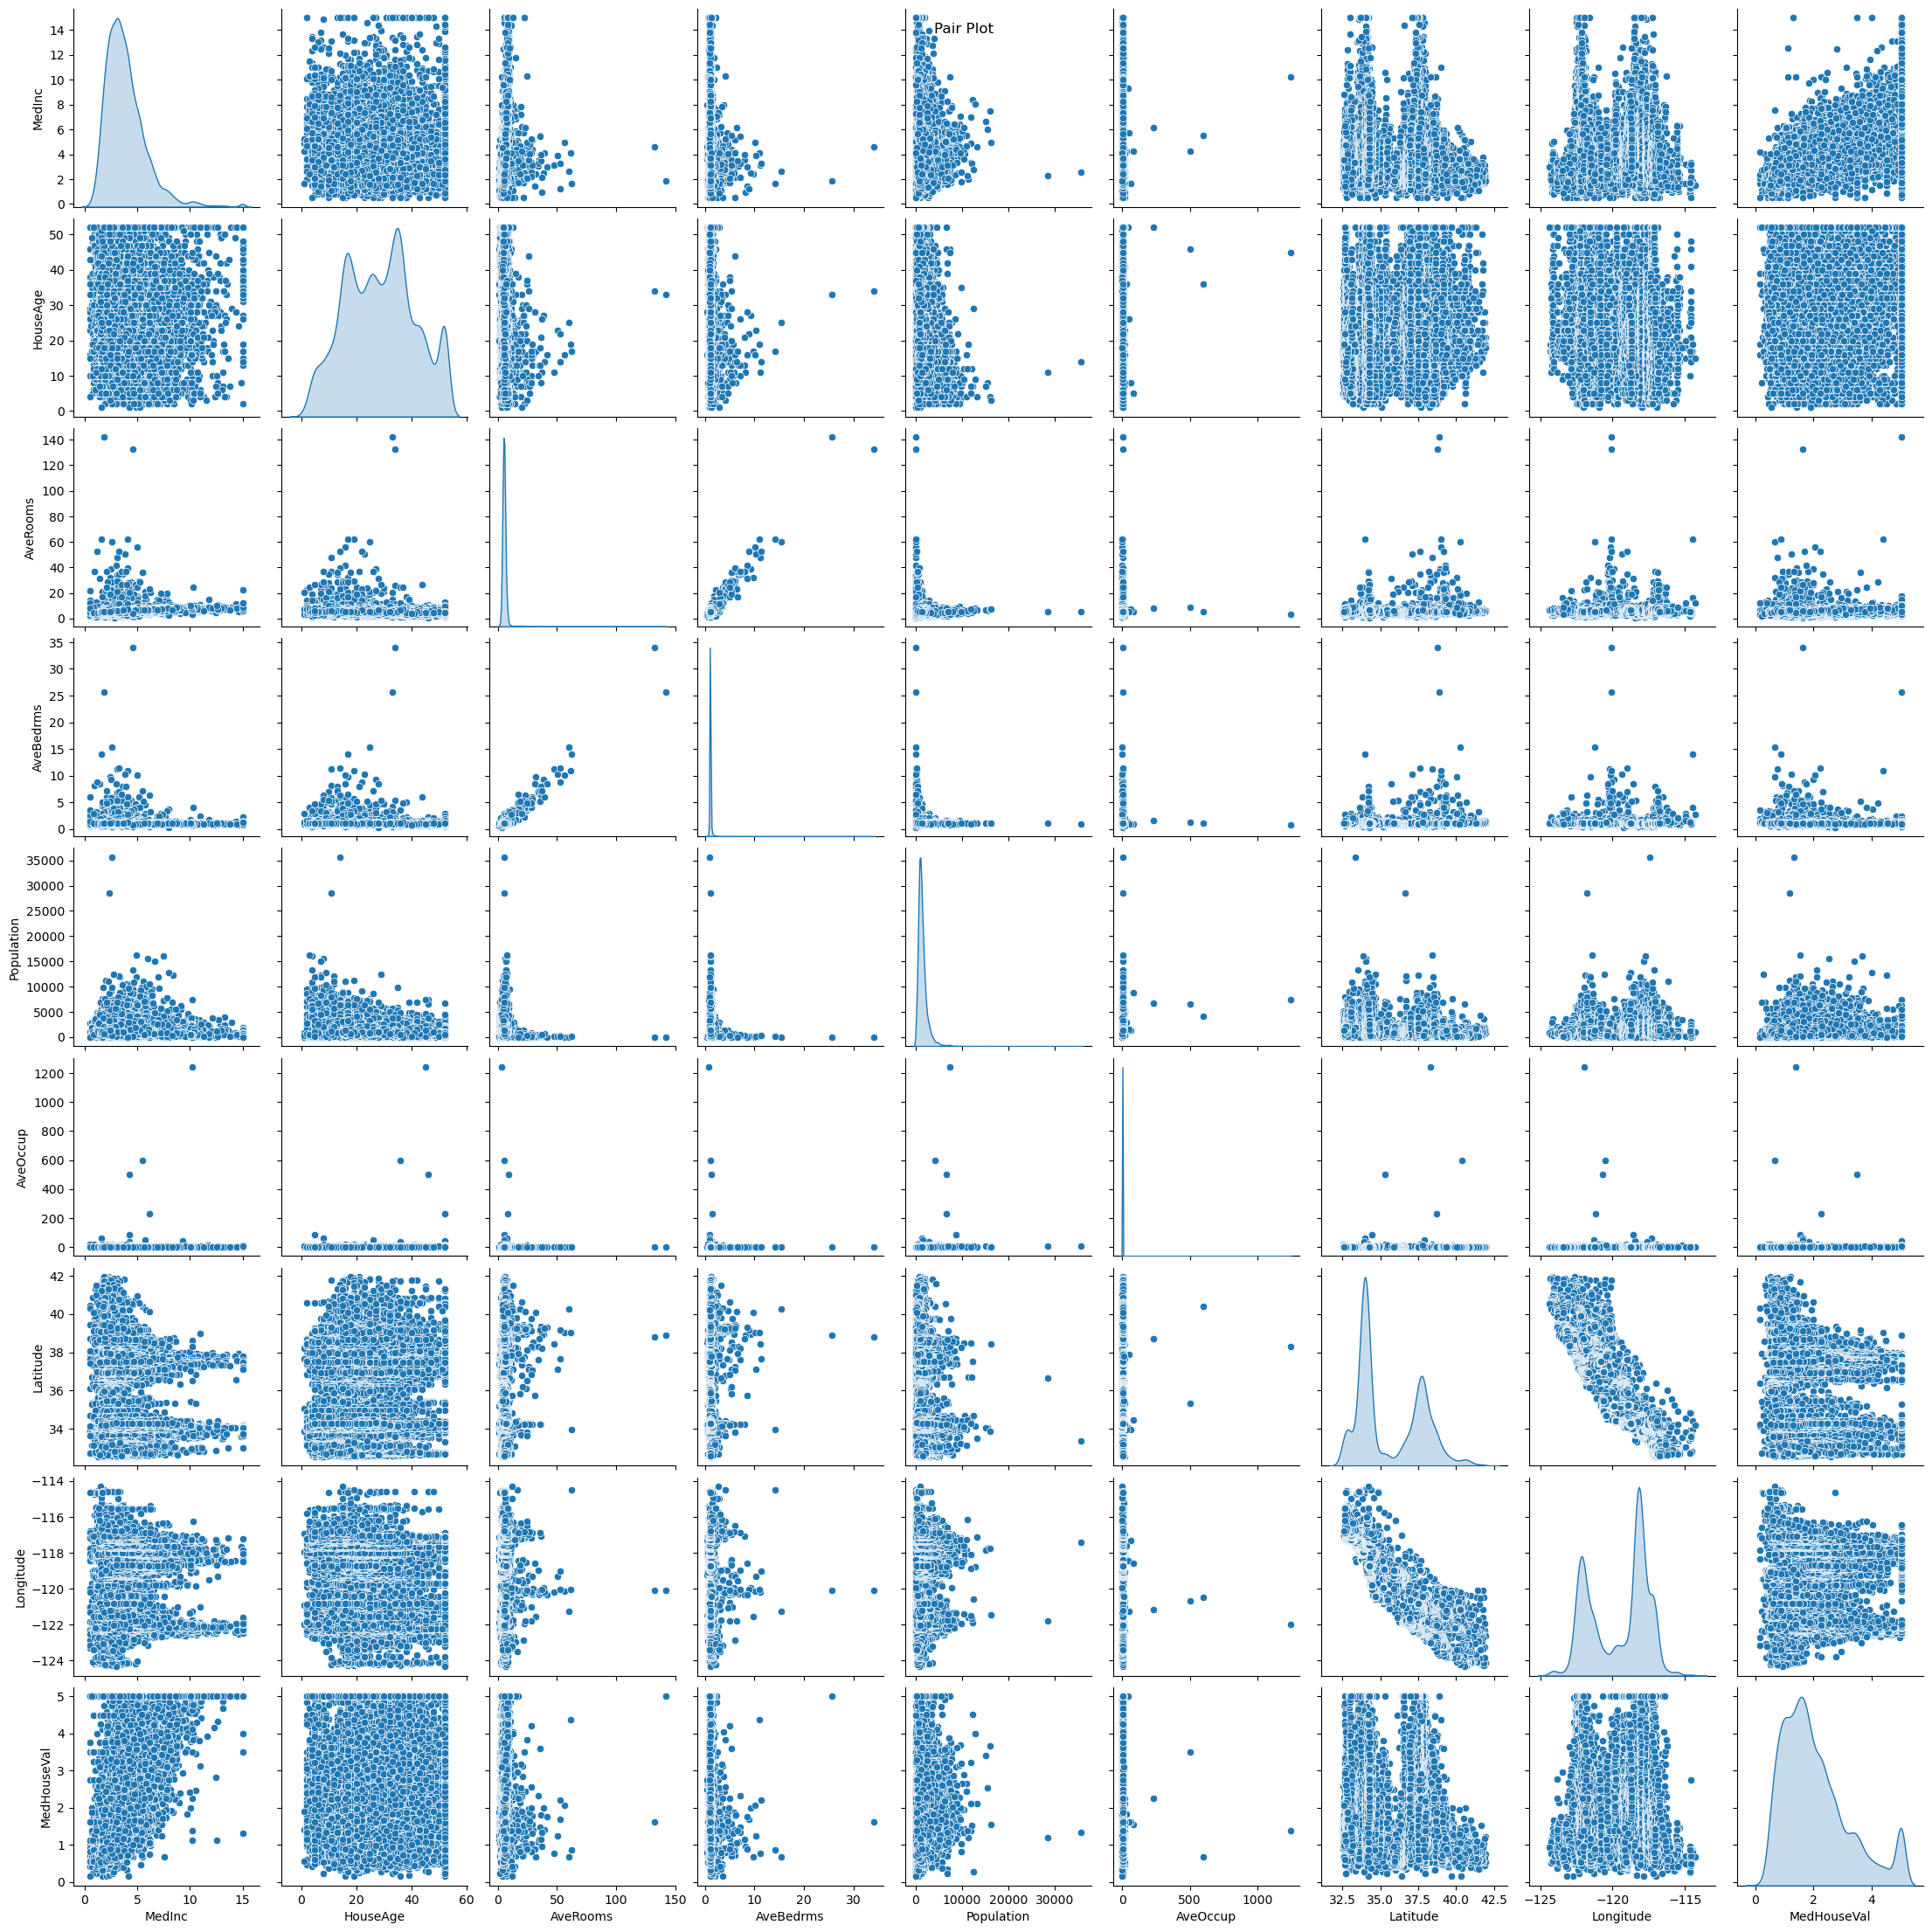

In [48]:
#PROGRAM 2
import pandas as ps 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

cd=fetch_california_housing(as_frame=True)
data=cd.frame

cm=data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix ')
plt.show()

sns.pairplot(data, diag_kind='kde')
plt.suptitle('Pair Plot ')
plt.show()


<Figure size 1200x800 with 0 Axes>

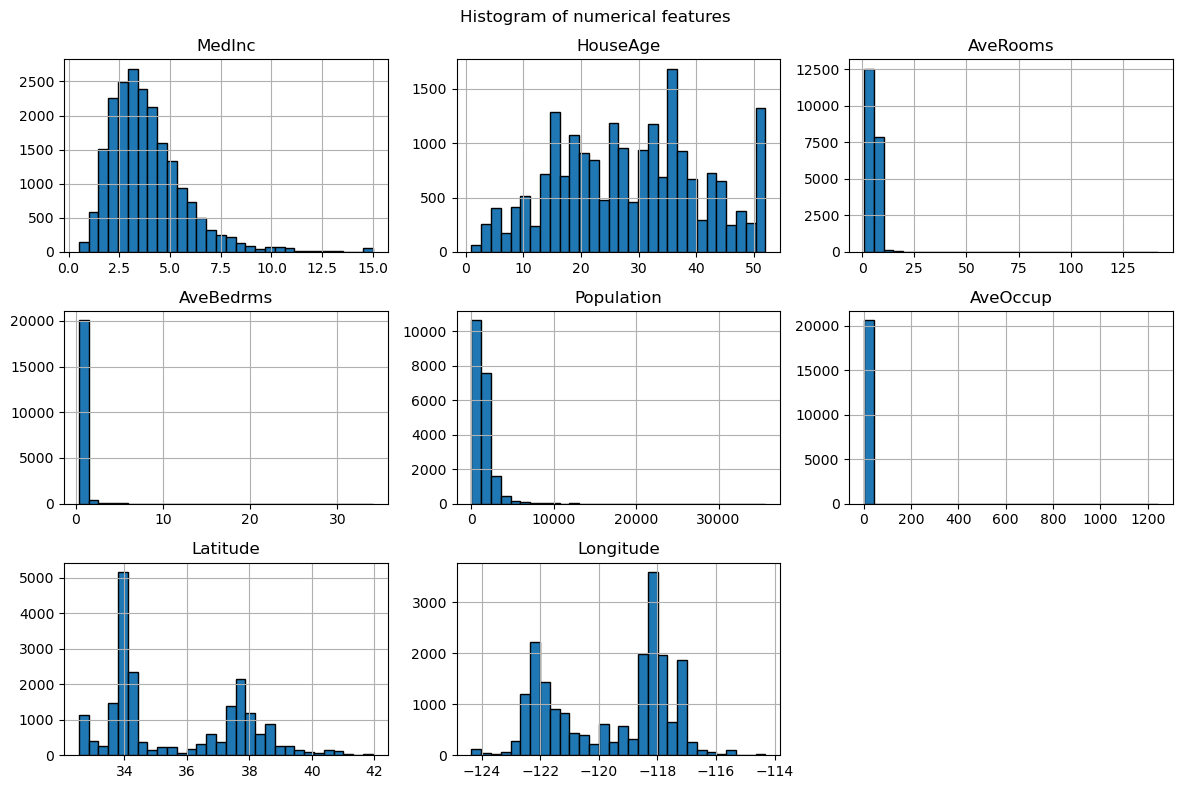

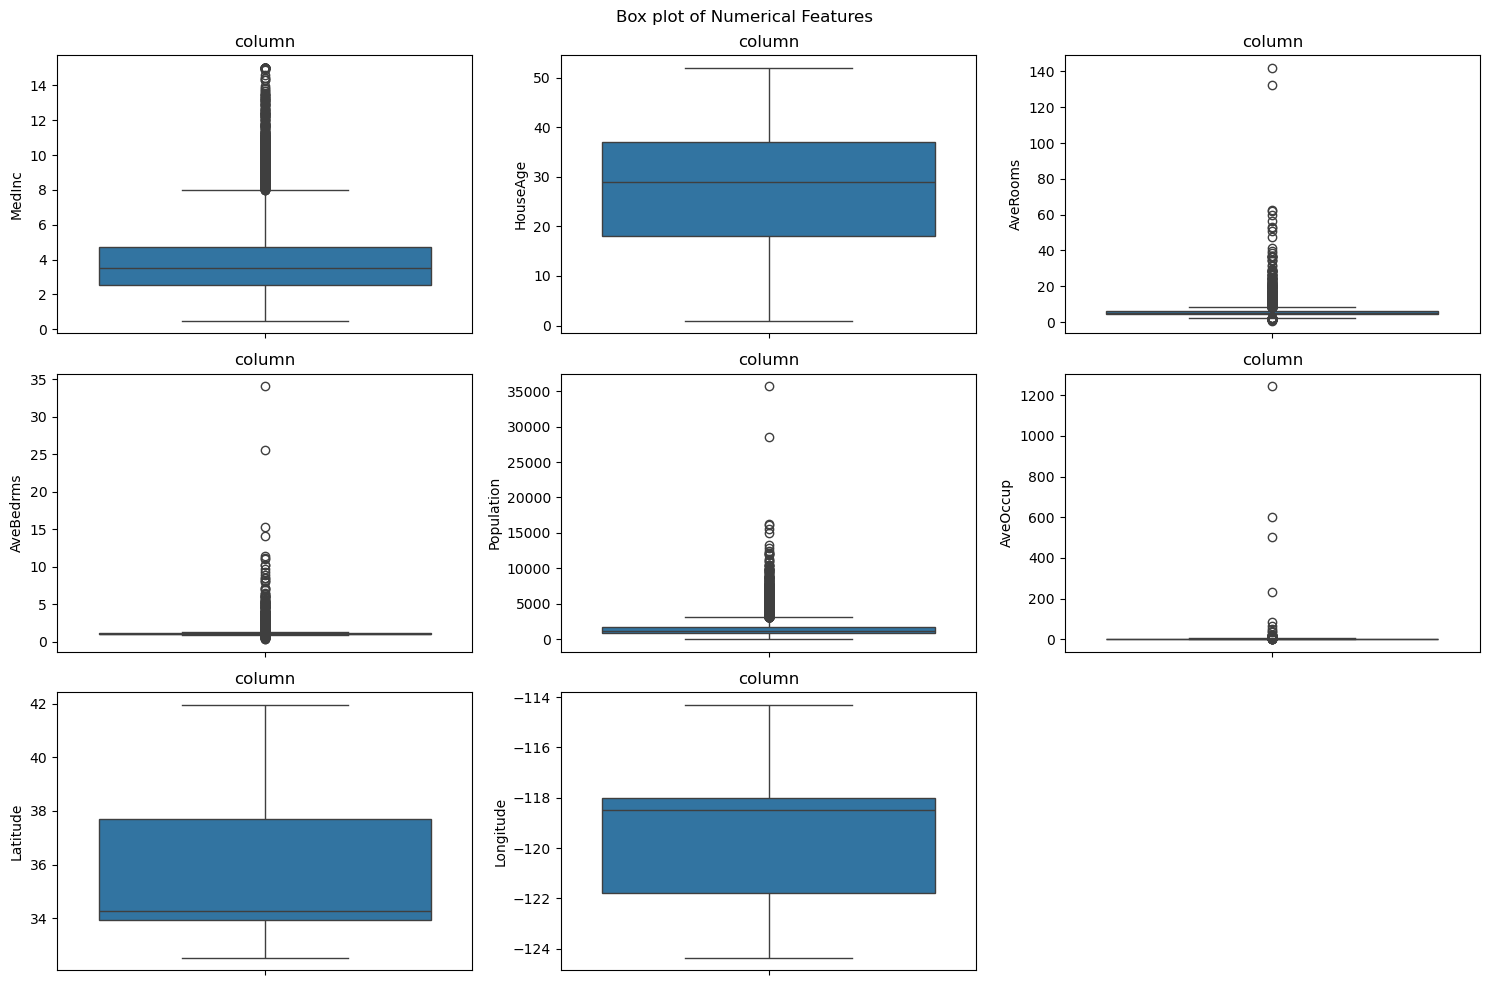

In [49]:
#PROGRAM 1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

cd = fetch_california_housing(as_frame=True)
df=pd.DataFrame(cd.data,columns=cd.feature_names)

plt.figure(figsize=(12, 8))
df.hist(bins=30,layout=(3,3),edgecolor='black')
plt.suptitle('Histogram of numerical features' )
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[column])
    plt.title('column')
plt.suptitle("Box plot of Numerical Features")
plt.tight_layout()
plt.show()




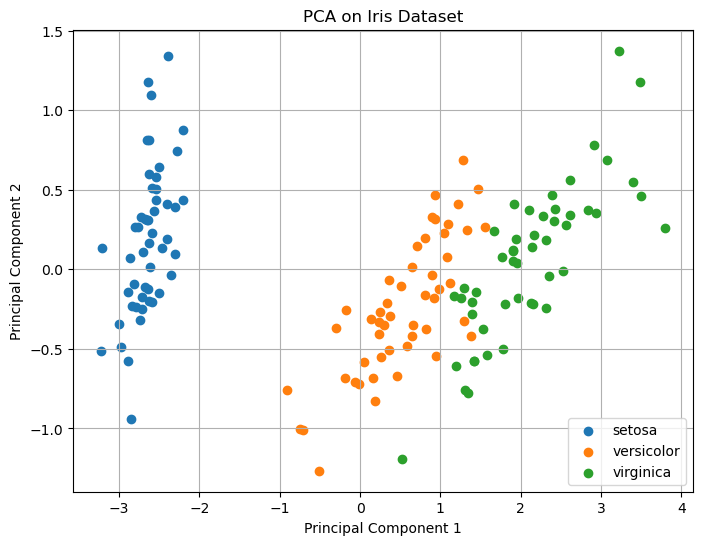

In [37]:
#Lab3
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

iris = load_iris()

data = iris.data
labels = iris.target

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(data)

df = pd.DataFrame(reduced_data, columns=['PC1','PC2'])
df['Label'] = labels

plt.figure(figsize=(8,6))

for label in np.unique(labels):
    plt.scatter(
        df[df['Label']==label]['PC1'],
        df[df['Label']==label]['PC2'],
        label=iris.target_names[label]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Iris Dataset")
plt.legend()
plt.grid()
plt.show()

In [70]:
import pandas as pd

def find_s_algorithm(file_path):

    data = pd.read_csv(file_path)

    print("Training Data:")
    print(data)

    attributes = data.columns[:-1]
    target = data.columns[-1]

    hypothesis = ['?' for i in attributes]

    for index, row in data.iterrows():

        if row[target] == 'Yes':

            for i, value in enumerate(row[attributes]):

                if hypothesis[i] == '?' :
                    hypothesis[i] = value
                else:
                    hypothesis[i] = '?'

    return hypothesis


file_path = "training_data.csv"

result = find_s_algorithm(file_path)

print("\nFinal Hypothesis:", result)

Training Data:
   Sunny  Warm Normal  Strong  warm    same  yes
0  Sunny  warm   High  Strong  warm    same  yes
1  Rainy  cold   High  Strong  warm  change   no
2  Sunny  Warm   High  Strong  cool  change  yes

Final Hypothesis: ['?', '?', '?', '?', '?', '?']


k = 1
['Class2', 'Class2', 'Class2', 'Class2', 'Class2', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class2', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', 'Class1', 'Class2', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class2', 'Class1', 'Class1', 'Class1']
k = 3
['Class2', 'Class2', 'Class2', 'Class2', 'Class2', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class2', 'Class2', 'Class2', 'Class1', 'Class2', 'Class2', 'Class2', 'Class2', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', 'Class1', 'Class2', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class1', 'Class2', 'Class1', 'Class1', 'Class2', 'Class2', 'Class1', 'Class

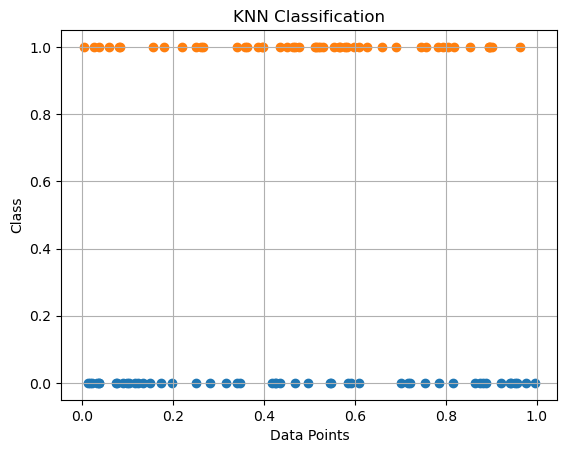

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

data = np.random.rand(100)

labels = ["Class1" if x <= 0.5 else "Class2" for x in data[:50]]

def distance(x1, x2):
    return abs(x1 - x2)

def knn(train_data, train_labels, test_point, k):

    distances = []

    for i in range(len(train_data)):
        distances.append((distance(test_point, train_data[i]), train_labels[i]))

    distances.sort()

    nearest = distances[:k]

    votes = [label for _, label in nearest]

    return Counter(votes).most_common(1)[0][0]


train_data = data[:50]
train_labels = labels

test_data = data[50:]

k_values = [1,3,5]

for k in k_values:

    print("k =", k)

    result = []

    for point in test_data:
        result.append(knn(train_data, train_labels, point, k))

    print(result)

plt.scatter(train_data, [0]*50)

plt.scatter(test_data, [1]*50)

plt.title("KNN Classification")
plt.xlabel("Data Points")
plt.ylabel("Class")

plt.grid()
plt.show()

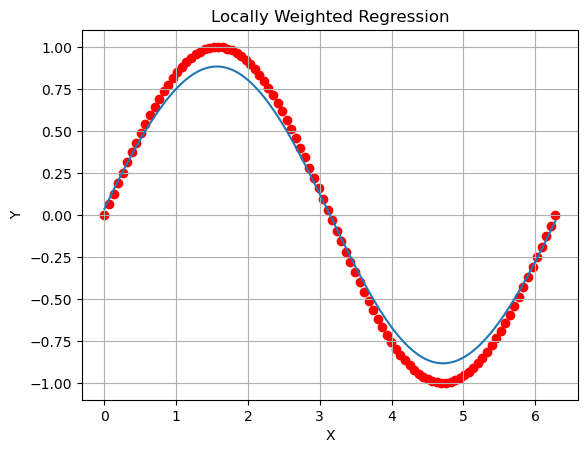

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def kernel(x, xi, tau):
    return np.exp(-np.sum((x-xi)**2)/(2*tau**2))

def LWR(x, X, y, tau):

    W = np.diag([kernel(x, X[i], tau) for i in range(len(X))])

    theta = np.linalg.inv(X.T@W@X) @ X.T @ W @ y

    return x @ theta

X = np.linspace(0, 2*np.pi, 100)
y = np.sin(X)

X = np.c_[np.ones(X.shape), X]

test = np.linspace(0,2*np.pi,200)
test_bias = np.c_[np.ones(test.shape), test]

tau = 0.5

pred = [LWR(x, X, y, tau) for x in test_bias]

plt.scatter(X[:,1], y,color='red')
plt.plot(test, pred)

plt.title("Locally Weighted Regression")
plt.xlabel("X")
plt.ylabel("Y")

plt.grid()
plt.show()

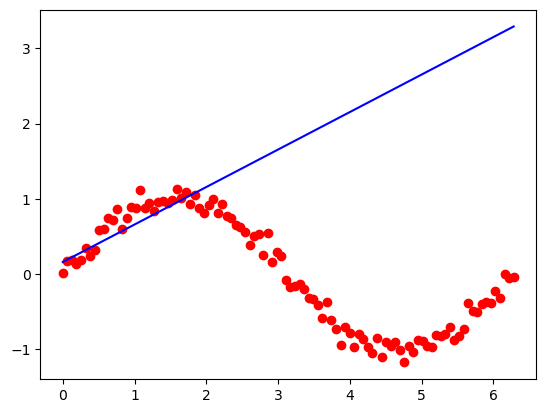

In [64]:
#6
import numpy as np
import matplotlib.pyplot as plt

X = np.linspace(0, 2*np.pi, 100)
y = np.sin(X) + 0.1*np.random.randn(100)

def lwr(x):
    w = np.exp(-(X-x)*2/(2*0.5*2))
    p = np.polyfit(X, y, 1, w=w)
    return np.polyval(p, x)

x_test = np.linspace(0, 2*np.pi, 200)
y_pred = [lwr(x) for x in x_test]

plt.scatter(X, y, c='red')
plt.plot(x_test, y_pred, c='blue')
plt.show()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\ADC\scikit_learn_data
Accuracy: 0.7416666666666667


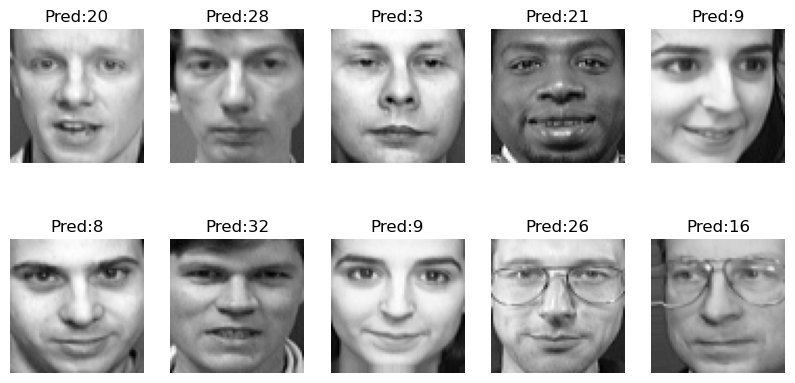

In [65]:
#9
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

faces = fetch_olivetti_faces()
X = faces.data
y = faces.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, img, p in zip(axes.ravel(), X_test[:10], y_pred[:10]):
    ax.imshow(img.reshape(64, 64), cmap='gray')
    ax.set_title("Pred:" + str(p))
    ax.axis('off')

plt.show()

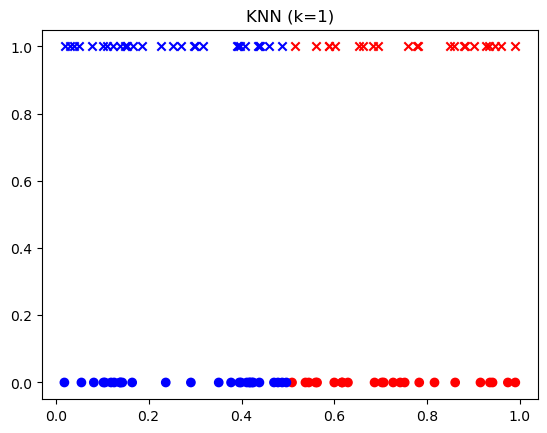

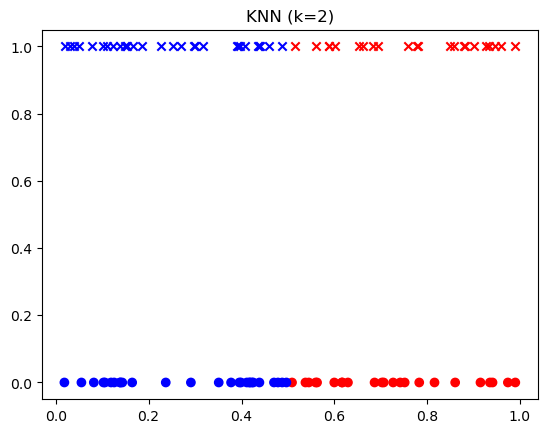

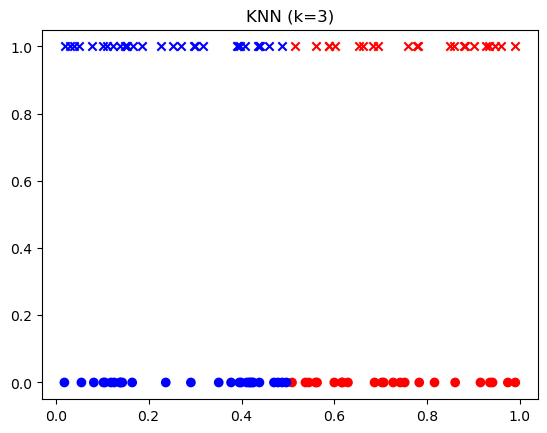

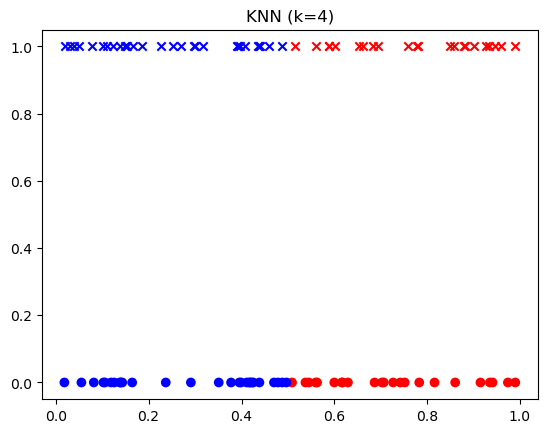

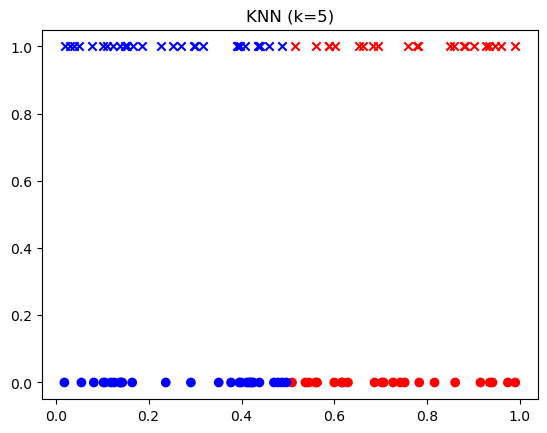

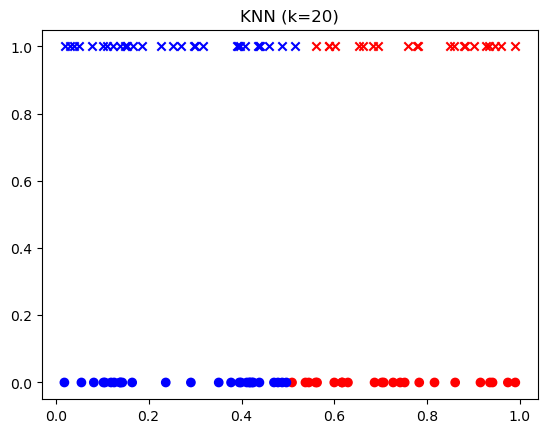

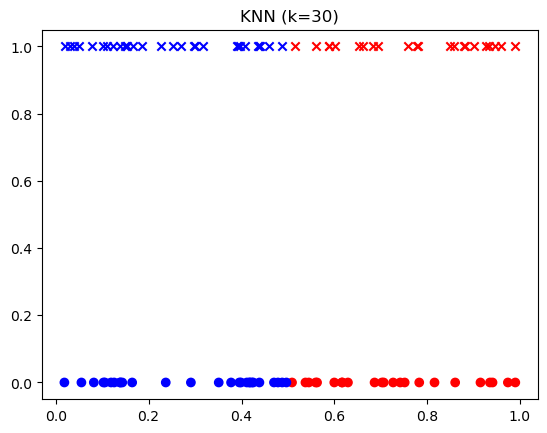

In [66]:
#5
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

d = np.random.rand(100)
tr, te = d[:50], d[50:]
lab = ['Class1' if x < 0.5 else 'Class2' for x in tr]

def knn(x, k):
    a = sorted([(abs(x-t), l) for t, l in zip(tr, lab)])
    return Counter([l for _, l in a[:k]]).most_common(1)[0][0]

for k in [1, 2, 3, 4, 5, 20, 30]:
    p = [knn(x, k) for x in te]
    c1 = [x for x, y in zip(te, p) if y == 'Class1']
    c2 = [x for x, y in zip(te, p) if y == 'Class2']

    plt.scatter(tr, [0]*50,
                c=['blue' if l == 'Class1' else 'red' for l in lab])
    plt.scatter(c1, [1]*len(c1), c='blue', marker='x')
    plt.scatter(c2, [1]*len(c2), c='red', marker='x')
    plt.title(f'KNN (k={k})')
    plt.show()

C:\Users\ADC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ADC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\ADC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ADC\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^


Confusion Matrix:
[[175  37]
 [ 13 344]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       212
           1       0.90      0.96      0.93       357

    accuracy                           0.91       569
   macro avg       0.92      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



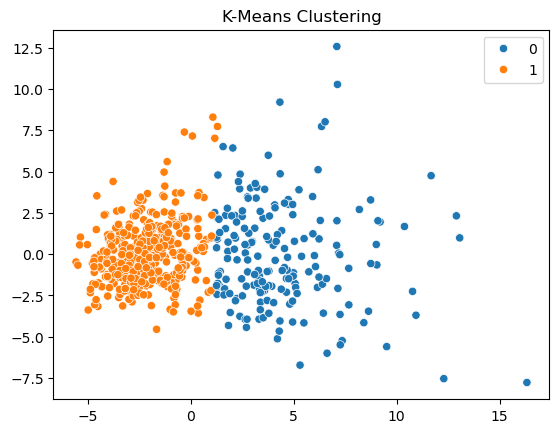

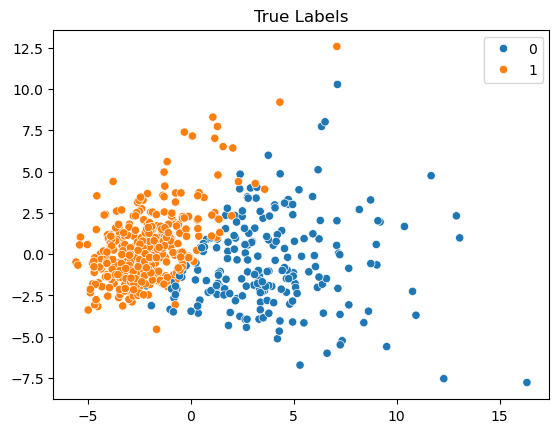

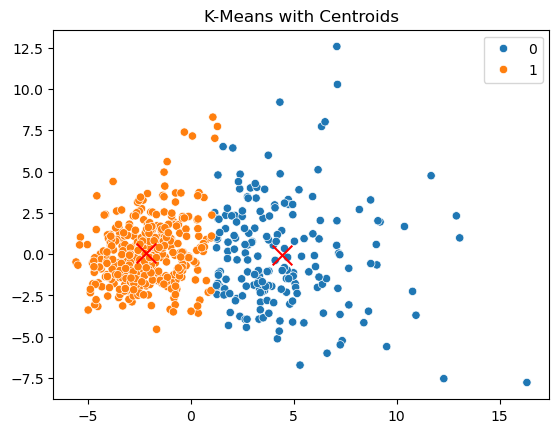

In [67]:
#10
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

data = load_breast_cancer()
X = data.data
y = data.target

X = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
pred = kmeans.fit_predict(X)

print("Confusion Matrix:")
print(confusion_matrix(y, pred))

print("\nClassification Report:")
print(classification_report(y, pred))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
centers = pca.transform(kmeans.cluster_centers_)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=pred)
plt.title("K-Means Clustering")
plt.show()

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y)
plt.title("True Labels")
plt.show()

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=pred)
plt.scatter(centers[:,0], centers[:,1],
            c='red', marker='x', s=200)
plt.title("K-Means with Centroids")
plt.show()